In [1]:
import torch
import matplotlib.pyplot as plt

from src.diffeomorphisms.vector.poincare import PoincareVectorDiffeomorphism
from src.manifolds.hyperbolic.vector.standard import StandardVectorHyperbolic

# seed
torch.manual_seed(0)

Embedded points shape: torch.Size([10, 2])


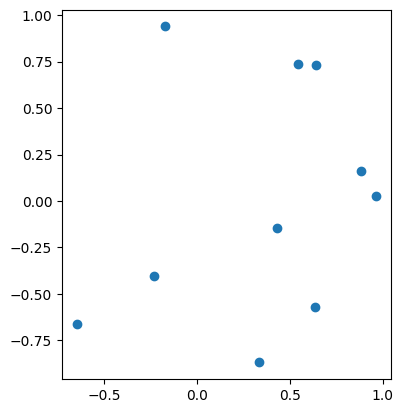

In [2]:
diffeo = PoincareVectorDiffeomorphism(d=2)
manifold = StandardVectorHyperbolic(d=2)

data = torch.randn(10, 2)
embedded = diffeo.forward(data)
print("Embedded points shape:", embedded.shape)

plt.scatter(embedded[:, 0].numpy(), embedded[:, 1].numpy())
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

inv_embedded shape: torch.Size([10, 2])
Reconstruction error: tensor([[ 1.1921e-07,  0.0000e+00],
        [ 2.9802e-08,  5.9605e-08],
        [ 1.1921e-07, -3.5763e-07],
        [ 2.9802e-08, -1.1921e-07],
        [ 0.0000e+00,  0.0000e+00],
        [ 1.1921e-07,  2.9802e-08],
        [-9.5367e-07, -1.0729e-06],
        [ 0.0000e+00, -5.9605e-08],
        [-1.1921e-07, -1.1921e-07],
        [ 0.0000e+00,  0.0000e+00]])


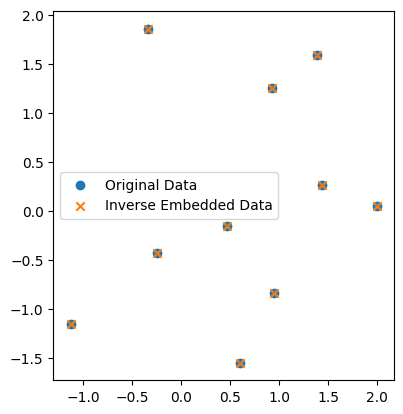

In [3]:
inv_embedded = diffeo.inverse(embedded)
print("inv_embedded shape:", inv_embedded.shape)
print("Reconstruction error:", data - inv_embedded)

# make plot with data and inverse embedded data with quiver arrow denoteing which is mapped to which
plt.scatter(data[:, 0].numpy(), data[:, 1].numpy(), label='Original Data')
plt.scatter(inv_embedded[:, 0].numpy(), inv_embedded[:, 1].numpy(), label='Inverse Embedded Data', marker='x')
for i in range(data.shape[0]):  
    plt.arrow(data[i, 0], data[i, 1],
              inv_embedded[i, 0] - data[i, 0],
              inv_embedded[i, 1] - data[i, 1],
              head_width=0.02, head_length=0.02, fc='gray', ec='gray', alpha=0.5)
plt.gca().set_aspect('equal', adjustable='box')
plt.legend()
plt.show()

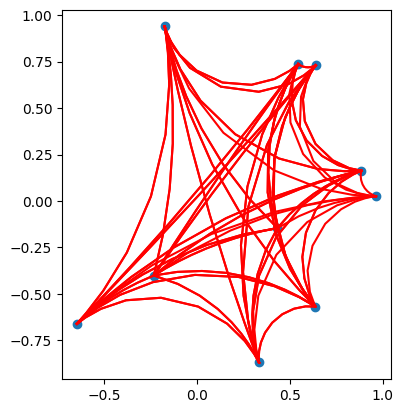

In [4]:
geodesics = manifold.geodesic(embedded[None], embedded[None], torch.linspace(0, 1, steps=10))

for i in range(geodesics.shape[1]):
    for j in range(geodesics.shape[2]-1):
        plt.plot(geodesics[0, i, j, :, 0].numpy(), geodesics[0, i, j, :, 1].numpy(), 'r-')
plt.scatter(embedded[:, 0].numpy(), embedded[:, 1].numpy())
plt.gca().set_aspect('equal', adjustable='box')
plt.show()